In [1]:
import os
import torch
import torchvision
import numpy as np
from PIL import Image
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import random
import time
import copy

In [2]:
DATA_ROOT = "/kaggle/input/trash-icra19"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
NUM_CLASSES = 3
OUTPUT_DIR = "outputs_mobilenet"
NUM_EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
RND_SEED = 42
IOU_THRESH = 0.5

In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
np.random.seed(RND_SEED)

In [4]:
def yolo_to_boxes(yolo_lines, img_w, img_h):
    boxes = []
    labels = []
    for line in yolo_lines:
        if isinstance(line, str):
            parts = line.strip().split()
        else:
            parts = line
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc = float(parts[1])
        yc = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])
        x_min = (xc - w/2.0) * img_w
        y_min = (yc - h/2.0) * img_h
        x_max = (xc + w/2.0) * img_w
        y_max = (yc + h/2.0) * img_h
        x_min = max(0., x_min)
        y_min = max(0., y_min)
        x_max = min(img_w - 1., x_max)
        y_max = min(img_h - 1., y_max)
        if x_max <= x_min or y_max <= y_min:
            continue
        boxes.append([x_min, y_min, x_max, y_max])
        labels.append(cls + 1)
    if len(boxes) == 0:
        return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

In [5]:
class TrashICRA19Dataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.images_dir = os.path.join(root_dir, "images")
        self.labels_dir = os.path.join(root_dir, "labels")
        assert os.path.isdir(self.images_dir), f"{self.images_dir} missing"
        assert os.path.isdir(self.labels_dir), f"{self.labels_dir} missing"
        self.img_files = sorted([f for f in os.listdir(self.images_dir) if f.lower().endswith((".jpg",".png",".jpeg"))])
        self.transforms = transforms

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        label_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + ".txt")
        img = Image.open(img_path).convert("RGB")
        img_w, img_h = img.size

        yolo_lines = []
        if os.path.exists(label_path):
            with open(label_path, "r") as fh:
                yolo_lines = [l.strip() for l in fh.readlines() if l.strip() != ""]
        boxes, labels = yolo_to_boxes(yolo_lines, img_w, img_h)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        if boxes.shape[0] > 0:
            area = (boxes[:,3] - boxes[:,1]) * (boxes[:,2] - boxes[:,0])
        else:
            area = torch.zeros((0,), dtype=torch.float32)
        target["area"] = area
        target["iscrowd"] = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        if self.transforms:
            img, target = self.transforms(img, target)
        else:
            img = F.to_tensor(img)

        return img, target

In [6]:
import torchvision.transforms as T
def get_transform(train):
    def transform(img, target):
        if train and random.random() < 0.5:
            img = F.hflip(img)
            if "boxes" in target and target["boxes"].shape[0] > 0:
                boxes = target["boxes"].clone()
                if isinstance(img, Image.Image):
                    w = img.width
                else:
                    w = img.shape[2]
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
                target["boxes"] = boxes
        if not isinstance(img, torch.Tensor):
            img = F.to_tensor(img)
        return img, target
    return transform


def collate_fn(batch):
    return tuple(zip(*batch))

In [7]:
train_ds = TrashICRA19Dataset(TRAIN_DIR, transforms=get_transform(train=True))
val_ds   = TrashICRA19Dataset(VAL_DIR, transforms=get_transform(train=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=1, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=1,       shuffle=False, num_workers=1, collate_fn=collate_fn)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")
img, target = train_ds[0]
print("Sample image tensor shape:", img.shape)
for k,v in target.items():
    print(k, "->", None if v is None else (v.shape if hasattr(v,'shape') else type(v)))

Train size: 5720, Val size: 820
Sample image tensor shape: torch.Size([3, 360, 480])
boxes -> torch.Size([2, 4])
labels -> torch.Size([2])
image_id -> torch.Size([1])
area -> torch.Size([2])
iscrowd -> torch.Size([2])


In [8]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes_total):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_total)
    return model

num_classes_total = NUM_CLASSES + 1
model = get_model(num_classes_total)
model.to(DEVICE)


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LEARNING_RATE, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
100%|██████████| 74.2M/74.2M [00:00<00:00, 174MB/s] 


In [13]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block):

In [9]:
def box_iou(boxA, boxB):
    if boxA.ndim == 1:
        boxA = boxA[None, :]
    if boxB.ndim == 1:
        boxB = boxB[None, :]
    N = boxA.shape[0]
    M = boxB.shape[0]
    iou = np.zeros((N, M), dtype=np.float32)
    for i in range(N):
        xa1, ya1, xa2, ya2 = boxA[i]
        for j in range(M):
            xb1, yb1, xb2, yb2 = boxB[j]
            inter_x1 = max(xa1, xb1)
            inter_y1 = max(ya1, yb1)
            inter_x2 = min(xa2, xb2)
            inter_y2 = min(ya2, yb2)
            inter_w = max(0., inter_x2 - inter_x1)
            inter_h = max(0., inter_y2 - inter_y1)
            inter_area = inter_w * inter_h
            areaA = max(0., (xa2 - xa1) * (ya2 - ya1))
            areaB = max(0., (xb2 - xb1) * (yb2 - yb1))
            union = areaA + areaB - inter_area
            if union > 0:
                iou[i, j] = inter_area / union
            else:
                iou[i, j] = 0.0
    return iou

In [10]:
def compute_ap(recall, precision):
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = max(mpre[i-1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = 0.0
    for i in idx:
        ap += (mrec[i+1] - mrec[i]) * mpre[i+1]
    return ap

In [11]:
def evaluate_map(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5):
    aps = []
    for cls in range(1, num_classes+1):
        preds = []
        gt_count = 0
        gts_for_image = {}
        for img_id, (p, g) in enumerate(zip(preds_by_image, gts_by_image)):
            gt_boxes = []
            if g is not None and "boxes" in g and len(g["boxes"])>0:
                mask = (g["labels"] == cls)
                if mask.sum().item() > 0:
                    boxes_np = g["boxes"][mask].cpu().numpy()
                    gt_boxes = [b for b in boxes_np]
            gt_count += len(gt_boxes)
            gts_for_image[img_id] = {"boxes": gt_boxes, "matched": [False]*len(gt_boxes)}
            if p is not None and "boxes" in p and len(p["boxes"])>0:
                maskp = (p["labels"] == cls)
                if maskp.sum().item() > 0:
                    boxes_np = p["boxes"][maskp].cpu().numpy()
                    scores_np = p["scores"][maskp].cpu().numpy()
                    for box, score in zip(boxes_np, scores_np):
                        preds.append({"image_id": img_id, "score": float(score), "box": box})
        if gt_count == 0:
            continue
        preds = sorted(preds, key=lambda x: x["score"], reverse=True)
        tp = np.zeros(len(preds), dtype=np.float32)
        fp = np.zeros(len(preds), dtype=np.float32)
        for i, pitem in enumerate(preds):
            img_id = pitem["image_id"]
            pred_box = pitem["box"]
            gt_info = gts_for_image[img_id]
            gt_boxes = np.array(gt_info["boxes"]) if len(gt_info["boxes"])>0 else np.zeros((0,4))
            if gt_boxes.shape[0] == 0:
                fp[i] = 1.0
                continue
            ious = box_iou(pred_box, gt_boxes)[0]
            max_iou_idx = ious.argmax()
            max_iou = ious[max_iou_idx]
            if max_iou >= iou_thresh and (not gt_info["matched"][max_iou_idx]):
                tp[i] = 1.0
                gts_for_image[img_id]["matched"][max_iou_idx] = True
            else:
                fp[i] = 1.0
        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / (gt_count + 1e-8)
        precisions = tp_cum / (tp_cum + fp_cum + 1e-8)
        if len(precisions) == 0:
            ap = 0.0
        else:
            ap = compute_ap(recalls, precisions)
        aps.append(ap)
    if len(aps) == 0:
        return 0.0
    return float(np.mean(aps)), aps

In [ ]:
best_map = -1.0
best_model_wts = None

for epoch in range(NUM_EPOCHS):
    start = time.time()
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    for images, targets in train_loader:
        images = list(img.to(DEVICE) for img in images)
        targets = [{k: v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        num_batches += 1

    epoch_loss = epoch_loss / max(1, num_batches)
    lr_scheduler.step()

    model.eval()
    preds_by_image = []
    gts_by_image = []
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(DEVICE) for img in images)
            outputs = model(images)
            pred = outputs[0] if len(outputs) > 0 else None
            if pred is not None:
                pred_cpu = {
                    "boxes": pred["boxes"].cpu() if "boxes" in pred else torch.zeros((0,4)),
                    "scores": pred["scores"].cpu() if "scores" in pred else torch.zeros((0,)),
                    "labels": pred["labels"].cpu() if "labels" in pred else torch.zeros((0,), dtype=torch.int64)
                }
            else:
                pred_cpu = None
            preds_by_image.append(pred_cpu)

            gt = targets[0]
            gt_cpu = {
                "boxes": gt["boxes"].cpu() if "boxes" in gt else torch.zeros((0,4)),
                "labels": gt["labels"].cpu() if "labels" in gt else torch.zeros((0,), dtype=torch.int64)
            }
            gts_by_image.append(gt_cpu)

    mean_ap, aps = evaluate_map(preds_by_image, gts_by_image, num_classes=NUM_CLASSES, iou_thresh=IOU_THRESH)
    elapsed = time.time() - start
    print(f"Train loss: {epoch_loss:.4f} | Val mAP@0.5: {mean_ap:.4f} | Time: {elapsed:.1f}s")

    if mean_ap > best_map:
        best_map = mean_ap
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, os.path.join(OUTPUT_DIR, "best_model_map.pth"))
        print(f"Saved best model (mAP {best_map:.4f}).")

    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"checkpoint_epoch_{epoch+1}.pth"))

print("Training complete. Best val mAP@0.5:", best_map)
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model_final_map.pth"))
    print("Best model saved to best_model_final_map.pth")

In [15]:
import matplotlib.pyplot as plt
def visualize_predictions(model, dataset, out_dir, device, n=10, score_thresh=0.5):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    for i in range(min(n, len(dataset))):
        img, target = dataset[i]
        with torch.no_grad():
            pred = model([img.to(device)])[0]
        img_np = img.mul(255).permute(1,2,0).byte().cpu().numpy()
        fig, ax = plt.subplots(1, figsize=(8,8))
        ax.imshow(img_np)
        for box in target["boxes"].cpu().numpy():
            x1,y1,x2,y2 = box
            rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='g', linewidth=2)
            ax.add_patch(rect)
        for box, score, label in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy(), pred["labels"].cpu().numpy()):
            if score < score_thresh:
                continue
            x1,y1,x2,y2 = box
            rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='r', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-4, f"{label}:{score:.2f}", color='white', backgroundcolor='black', fontsize=8)
        ax.axis("off")
        plt.tight_layout()
        out_path = os.path.join(out_dir, f"pred_{i}.png")
        fig.savefig(out_path)
        plt.close(fig)

# visualize_predictions(model, val_ds, os.path.join(OUTPUT_DIR, "preds"), DEVICE, n=10, score_thresh=0.4)
# print("Example predictions saved in", os.path.join(OUTPUT_DIR, "preds"))

In [16]:
TEST_DIR = os.path.join(DATA_ROOT, "test")

test_ds = TrashICRA19Dataset(TEST_DIR, transforms=get_transform(train=False))

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    collate_fn=collate_fn
)

print("Test size:", len(test_ds))

Test size: 1144


In [17]:
best_model_path = os.path.join("", "/kaggle/input/mobilenet-under-water-object-detection/pytorch/default/1/outputs_mobilenet/best_model_final_map.pth")

model = get_model(NUM_CLASSES + 1)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Loaded model:", best_model_path)

Loaded model: /kaggle/input/mobilenet-under-water-object-detection/pytorch/default/1/outputs_mobilenet/best_model_final_map.pth


In [18]:
preds_by_image = []
gts_by_image   = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(DEVICE) for img in images]

        outputs = model(images)
        pred = outputs[0]

        pred_cpu = {
            "boxes": pred["boxes"].cpu(),
            "scores": pred["scores"].cpu(),
            "labels": pred["labels"].cpu()
        }
        preds_by_image.append(pred_cpu)

        # Ground truth
        gt = targets[0]
        gt_cpu = {
            "boxes": gt["boxes"].cpu(),
            "labels": gt["labels"].cpu()
        }
        gts_by_image.append(gt_cpu)

In [19]:
test_map, class_aps = evaluate_map(
    preds_by_image,
    gts_by_image,
    num_classes=NUM_CLASSES,
    iou_thresh=0.5
)

print(f"\nTEST RESULT")
print(f"Test mAP@0.5: {test_map:.4f}")

for i, ap in enumerate(class_aps, start=1):
    print(f"Class {i} AP: {ap:.4f}")


TEST RESULT
Test mAP@0.5: 0.9395
Class 1 AP: 0.9739
Class 2 AP: 0.9110
Class 3 AP: 0.9334


In [20]:
visualize_predictions(
    model,
    test_ds,
    out_dir=os.path.join(OUTPUT_DIR, "test_preds"),
    device=DEVICE,
    n=len(test_ds),
    score_thresh=0.4
)

In [21]:
CLASS_NAMES = {
    1: "plastic",
    2: "biological",
    3: "rov"
}

In [22]:
import random
import matplotlib.pyplot as plt

def run_inference(
    model,
    dataset,
    device,
    num_samples=100,
    score_thresh=0.4,
    out_dir="random_test_preds"
):
    os.makedirs(out_dir, exist_ok=True)

    model.eval()
    total_images = len(dataset)

    indices = random.sample(range(total_images), min(num_samples, total_images))
    print(f"Running inference on {len(indices)} random test images...")

    for idx in indices:
        img, target = dataset[idx]

        with torch.no_grad():
            pred = model([img.to(device)])[0]

        img_np = img.mul(255).permute(1,2,0).byte().cpu().numpy()

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img_np)

        for box, label in zip(target["boxes"].numpy(), target["labels"].numpy()):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                 fill=False, edgecolor='g', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-4, f"GT: {CLASS_NAMES.get(label,'?')}",
                    color="white", backgroundcolor="green", fontsize=8)

        for box, score, label in zip(
            pred["boxes"].cpu().numpy(),
            pred["scores"].cpu().numpy(),
            pred["labels"].cpu().numpy()
        ):
            if score < score_thresh:
                continue

            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                 fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)

            class_name = CLASS_NAMES.get(label, f"cls{label}")
            ax.text(
                x1,
                y1-6,
                f"{class_name} ({score:.2f})",
                fontsize=8,
                color="white",
                backgroundcolor="red"
            )

        ax.axis("off")
        plt.tight_layout()

        save_path = os.path.join(out_dir, f"random_pred_{idx}.png")
        fig.savefig(save_path)
        plt.close(fig)

    print(f"Saved random inference results to: {out_dir}")

In [23]:
run_inference(
    model=model,
    dataset=test_ds,
    device=DEVICE,
    num_samples=100,
    score_thresh=0.4,
    out_dir=os.path.join(OUTPUT_DIR, "100_test_predictions")
)

Running inference on 100 random test images...
Saved random inference results to: outputs_mobilenet/100_test_predictions


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import math
EPS = 1e-8

In [25]:
def box_iou_np(boxA, boxB):
    boxA = np.array(boxA, dtype=np.float32)
    boxB = np.array(boxB, dtype=np.float32)
    if boxA.ndim == 1:
        boxA = boxA[None, :]
    N = boxA.shape[0]
    M = boxB.shape[0]
    iou = np.zeros((N, M), dtype=np.float32)
    for i in range(N):
        xa1, ya1, xa2, ya2 = boxA[i]
        areaA = max(0., (xa2 - xa1)) * max(0., (ya2 - ya1))
        for j in range(M):
            xb1, yb1, xb2, yb2 = boxB[j]
            inter_x1 = max(xa1, xb1)
            inter_y1 = max(ya1, yb1)
            inter_x2 = min(xa2, xb2)
            inter_y2 = min(ya2, yb2)
            inter_w = max(0., inter_x2 - inter_x1)
            inter_h = max(0., inter_y2 - inter_y1)
            inter_area = inter_w * inter_h
            areaB = max(0., (xb2 - xb1)) * max(0., (yb2 - yb1))
            union = areaA + areaB - inter_area
            if union > 0:
                iou[i, j] = inter_area / union
            else:
                iou[i, j] = 0.0
    if iou.shape[0] == 1:
        return iou[0]
    return iou

In [26]:
def build_pred_list(preds_by_image):
    preds = []
    for img_id, p in enumerate(preds_by_image):
        if p is None:
            continue
        boxes = p.get("boxes", None)
        scores = p.get("scores", None)
        labels = p.get("labels", None)
        if boxes is None or len(boxes) == 0:
            continue
        boxes_np = boxes.cpu().numpy() if hasattr(boxes, "cpu") else np.array(boxes)
        scores_np = scores.cpu().numpy() if hasattr(scores, "cpu") else np.array(scores)
        labels_np = labels.cpu().numpy() if hasattr(labels, "cpu") else np.array(labels)
        for box, score, lbl in zip(boxes_np, scores_np, labels_np):
            preds.append({"image_id": img_id, "score": float(score), "box": box, "label": int(lbl)})
    return preds

In [27]:
def build_gt_dict(gts_by_image):
    gts = {}
    for img_id, g in enumerate(gts_by_image):
        boxes = g.get("boxes", None)
        labels = g.get("labels", None)
        lst = []
        if boxes is None or len(boxes) == 0:
            gts[img_id] = lst
            continue
        boxes_np = boxes.cpu().numpy() if hasattr(boxes, "cpu") else np.array(boxes)
        labels_np = labels.cpu().numpy() if hasattr(labels, "cpu") else np.array(labels)
        for box, lbl in zip(boxes_np, labels_np):
            lst.append({"box": box, "label": int(lbl), "matched": False})
        gts[img_id] = lst
    return gts

In [28]:
def pr_curve_and_ap_for_class(preds, gts_by_image, cls, iou_thresh=0.5):
    cls_preds = [p for p in preds if p["label"] == cls]
    if len(cls_preds) == 0:
        return np.array([]), np.array([]), np.array([]), 0.0
    cls_preds = sorted(cls_preds, key=lambda x: x["score"], reverse=True)
    tp = np.zeros(len(cls_preds), dtype=np.float32)
    fp = np.zeros(len(cls_preds), dtype=np.float32)
    gt_count = 0
    for img_id, g_list in gts_by_image.items():
        for g in g_list:
            if g["label"] == cls:
                gt_count += 1

    matched = {img_id: [False]*len(gts_by_image[img_id]) for img_id in gts_by_image}

    for i, p in enumerate(cls_preds):
        img_id = p["image_id"]
        pred_box = p["box"]
        g_list = gts_by_image.get(img_id, [])
        # gather gt boxes of this class in that image
        gt_boxes = []
        gt_idxs = []
        for idx, g in enumerate(g_list):
            if g["label"] == cls:
                gt_boxes.append(g["box"])
                gt_idxs.append(idx)
        if len(gt_boxes) == 0:
            fp[i] = 1.0
            continue
        ious = box_iou_np(pred_box, np.array(gt_boxes))
        best_idx = ious.argmax()
        best_iou = float(ious[best_idx])
        global_gt_idx = gt_idxs[best_idx]
        if best_iou >= iou_thresh and (not matched[img_id][global_gt_idx]):
            tp[i] = 1.0
            matched[img_id][global_gt_idx] = True
        else:
            fp[i] = 1.0

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    precisions = tp_cum / (tp_cum + fp_cum + EPS)
    recalls = tp_cum / (gt_count + EPS)
    scores = np.array([p["score"] for p in cls_preds], dtype=np.float32)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for k in range(mpre.size-1, 0, -1):
        mpre[k-1] = max(mpre[k-1], mpre[k])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = 0.0
    for k in idx:
        ap += (mrec[k+1] - mrec[k]) * mpre[k+1]

    return recalls, precisions, scores, float(ap)

In [29]:
def compute_map_range(preds_by_image, gts_by_image, num_classes, iou_values=None):
    if iou_values is None:
        iou_values = np.arange(0.5, 0.96, 0.05)
    preds = build_pred_list(preds_by_image)
    gts = build_gt_dict(gts_by_image)

    per_class_maps = []
    for cls in range(1, num_classes+1):
        ap_per_iou = []
        for iou in iou_values:
            _, _, _, ap = pr_curve_and_ap_for_class(preds, gts, cls, iou_thresh=iou)
            ap_per_iou.append(ap)
        per_class_maps.append(float(np.mean(ap_per_iou)))
    mean_map = float(np.mean(per_class_maps)) if len(per_class_maps) > 0 else 0.0
    return mean_map, per_class_maps, iou_values

In [30]:
def evaluate_at_threshold(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5, score_thresh=0.5):
    preds = build_pred_list(preds_by_image)
    gts = build_gt_dict(gts_by_image)
    preds = [p for p in preds if p["score"] >= score_thresh]

    matched = {img_id: [False]*len(gts[img_id]) for img_id in gts}

    per_class_TP = defaultdict(int)
    per_class_FP = defaultdict(int)
    per_class_FN = defaultdict(int)
    support = defaultdict(int)

    for img_id, glist in gts.items():
        for g in glist:
            support[g["label"]] += 1

    preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)

    for p in preds_sorted:
        img_id = p["image_id"]
        pred_box = p["box"]
        pred_cls = p["label"]
        g_list = gts.get(img_id, [])
        gt_boxes = []
        gt_idxs = []
        for idx, g in enumerate(g_list):
            if g["label"] == pred_cls:
                gt_boxes.append(g["box"])
                gt_idxs.append(idx)
        if len(gt_boxes) == 0:
            # no gt of this class in image -> false positive
            per_class_FP[pred_cls] += 1
            continue
        ious = box_iou_np(pred_box, np.array(gt_boxes))
        best_idx = int(np.argmax(ious))
        best_iou = float(ious[best_idx])
        global_gt_idx = gt_idxs[best_idx]
        if best_iou >= iou_thresh and (not matched[img_id][global_gt_idx]):
            per_class_TP[pred_cls] += 1
            matched[img_id][global_gt_idx] = True
        else:
            per_class_FP[pred_cls] += 1

    for img_id, g_list in gts.items():
        for idx, g in enumerate(g_list):
            if not matched[img_id][idx]:
                per_class_FN[g["label"]] += 1

    results = {}
    for cls in range(1, num_classes+1):
        TP = per_class_TP.get(cls, 0)
        FP = per_class_FP.get(cls, 0)
        FN = per_class_FN.get(cls, 0)
        P = TP / (TP + FP + EPS)
        R = TP / (TP + FN + EPS)
        F1 = 2 * P * R / (P + R + EPS)
        results[cls] = {"TP": TP, "FP": FP, "FN": FN, "Precision": P, "Recall": R, "F1": F1, "Support": support.get(cls, 0)}
    # overall micro metrics
    TP_tot = sum([results[c]["TP"] for c in results])
    FP_tot = sum([results[c]["FP"] for c in results])
    FN_tot = sum([results[c]["FN"] for c in results])
    P_micro = TP_tot / (TP_tot + FP_tot + EPS)
    R_micro = TP_tot / (TP_tot + FN_tot + EPS)
    F1_micro = 2 * P_micro * R_micro / (P_micro + R_micro + EPS)
    results["micro_avg"] = {"TP": TP_tot, "FP": FP_tot, "FN": FN_tot, "Precision": P_micro, "Recall": R_micro, "F1": F1_micro, "Support": sum(results[c]["Support"] for c in results if isinstance(c, int))}
    return results

In [39]:
def detection_confusion_matrix(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5, score_thresh=0.5):
    preds = build_pred_list(preds_by_image)
    gts = build_gt_dict(gts_by_image)

    preds = [p for p in preds if p["score"] >= score_thresh]

    M = np.zeros((num_classes+1, num_classes+1), dtype=np.int32)
    matched = {img_id: [False]*len(gts[img_id]) for img_id in gts}

    preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)

    for p in preds_sorted:
        img_id = p["image_id"]
        p_box = p["box"]
        p_cls = p["label"]

        g_list = gts.get(img_id, [])

        if len(g_list) == 0:
            M[-1, p_cls-1] += 1
            continue

        gt_boxes = np.array([g["box"] for g in g_list])

        # ---- FIXED IOU CALL ----
        ious = box_iou_np(p_box, gt_boxes)  # shape = (num_gt,)
        best_idx = int(np.argmax(ious))
        best_iou = float(ious[best_idx])

        if best_iou >= iou_thresh and not matched[img_id][best_idx]:
            true_cls = g_list[best_idx]["label"]
            M[true_cls-1, p_cls-1] += 1
            matched[img_id][best_idx] = True
        else:
            M[-1, p_cls-1] += 1

    for img_id, g_list in gts.items():
        for idx, g in enumerate(g_list):
            if not matched[img_id][idx]:
                true_cls = g["label"]
                M[true_cls-1, -1] += 1

    row_labels = [CLASS_NAMES.get(i, f"class{i}") for i in range(1, num_classes+1)] + ["no_gt"]
    col_labels = [CLASS_NAMES.get(i, f"class{i}") for i in range(1, num_classes+1)] + ["no_pred"]
    return M, row_labels, col_labels

In [32]:
def metrics_vs_confidence(preds_by_image, gts_by_image, cls, num_classes, iou_thresh=0.5, confidence_grid=None):
    if confidence_grid is None:
        confidence_grid = np.linspace(0.0, 1.0, 101)
    confs = []
    precisions = []
    recalls = []
    f1s = []
    for thr in confidence_grid:
        res = evaluate_at_threshold(preds_by_image, gts_by_image, num_classes, iou_thresh=iou_thresh, score_thresh=thr)
        r = res.get(cls, None)
        if r is None:
            precisions.append(0.0)
            recalls.append(0.0)
            f1s.append(0.0)
        else:
            precisions.append(r["Precision"])
            recalls.append(r["Recall"])
            f1s.append(r["F1"])
        confs.append(thr)
    return {"confs": np.array(confs), "precision": np.array(precisions), "recall": np.array(recalls), "f1": np.array(f1s)}

In [33]:
def plot_precision_recall_curve_for_classes(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5):
    preds = build_pred_list(preds_by_image)
    gts = build_gt_dict(gts_by_image)
    plt.figure(figsize=(8,6))
    for cls in range(1, num_classes+1):
        recalls, precisions, scores, ap = pr_curve_and_ap_for_class(preds, gts, cls, iou_thresh=iou_thresh)
        if len(recalls) == 0:
            continue
        plt.plot(recalls, precisions, label=f"{CLASS_NAMES.get(cls,'cls'+str(cls))} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (IoU={iou_thresh})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confidence_curves(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5):
    grid = np.linspace(0.0, 1.0, 101)
    plt.figure(figsize=(8,6))
    for cls in range(1, num_classes+1):
        res = metrics_vs_confidence(preds_by_image, gts_by_image, cls, num_classes, iou_thresh=iou_thresh, confidence_grid=grid)
        plt.plot(res["confs"], res["f1"], label=f"{CLASS_NAMES.get(cls)}")
    plt.xlabel("Confidence")
    plt.ylabel("F1")
    plt.title("F1 vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,6))
    for cls in range(1, num_classes+1):
        res = metrics_vs_confidence(preds_by_image, gts_by_image, cls, num_classes, iou_thresh=iou_thresh, confidence_grid=grid)
        plt.plot(res["confs"], res["precision"], label=f"{CLASS_NAMES.get(cls)}")
    plt.xlabel("Confidence")
    plt.ylabel("Precision")
    plt.title("Precision vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,6))
    for cls in range(1, num_classes+1):
        res = metrics_vs_confidence(preds_by_image, gts_by_image, cls, num_classes, iou_thresh=iou_thresh, confidence_grid=grid)
        plt.plot(res["confs"], res["recall"], label=f"{CLASS_NAMES.get(cls)}")
    plt.xlabel("Confidence")
    plt.ylabel("Recall")
    plt.title("Recall vs Confidence Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [34]:
def results_dataframe_and_plot(per_class_map50_95, support_list):
    rows = []
    for i, ap in enumerate(per_class_map50_95, start=1):
        rows.append({"Class": CLASS_NAMES.get(i, f"cls{i}"), "Support": support_list[i-1], "AP@50-95": ap})
    df = pd.DataFrame(rows)
    plt.figure(figsize=(6,5))
    plt.bar(df["Class"], df["AP@50-95"])
    plt.title("mAP50-95 per Class")
    plt.ylabel("mAP")
    plt.xlabel("Class")
    plt.ylim(0, 1.0)
    plt.grid(axis='y')
    plt.show()
    return df

In [40]:
def run_all_metrics_and_plots(preds_by_image, gts_by_image, NUM_CLASSES,
                              iou_for_metrics=0.5, compute_map50_95=True):
    mean_map50, aps50, _ = compute_map_range(
        preds_by_image, gts_by_image, NUM_CLASSES, iou_values=np.array([0.5])
    )
    print(f"mAP@0.5 (mean over classes): {mean_map50:.4f}")
    for i, ap in enumerate(aps50, start=1):
        print(f"Class {i} ({CLASS_NAMES.get(i)}): AP@0.5 = {ap:.4f}")

    if compute_map50_95:
        mean_map5095, per_class_map5095, ious = compute_map_range(preds_by_image, gts_by_image, NUM_CLASSES)
        print(f"mAP@50-95 (mean over classes & IoUs): {mean_map5095:.4f}")
        for i, ap in enumerate(per_class_map5095, start=1):
            print(f"Class {i} ({CLASS_NAMES.get(i)}): AP@50-95 = {ap:.4f}")
    else:
        mean_map5095 = None
        per_class_map5095 = [None]*NUM_CLASSES

    res_at_04 = evaluate_at_threshold(preds_by_image, gts_by_image, NUM_CLASSES, iou_thresh=iou_for_metrics, score_thresh=0.4)
    print("\nMetrics at score_thresh=0.4, IoU=", iou_for_metrics)
    for cls in range(1, NUM_CLASSES+1):
        r = res_at_04.get(cls)
        print(f"Class {cls} ({CLASS_NAMES.get(cls)}): Precision={r['Precision']:.3f} Recall={r['Recall']:.3f} F1={r['F1']:.3f} Support={r['Support']}")
    print("Micro avg:", res_at_04["micro_avg"])

    cm, rows, cols = detection_confusion_matrix(preds_by_image, gts_by_image, NUM_CLASSES, iou_thresh=iou_for_metrics, score_thresh=0.4)
    print("\nConfusion matrix (rows=true, cols=predicted). Last row = no_gt (false positives), last col = no_pred (misses):")
    print(pd.DataFrame(cm, index=rows, columns=cols))

    plot_precision_recall_curve_for_classes(preds_by_image, gts_by_image, NUM_CLASSES, iou_thresh=iou_for_metrics)

    plot_confidence_curves(preds_by_image, gts_by_image, NUM_CLASSES, iou_thresh=iou_for_metrics)

    gts = build_gt_dict(gts_by_image)
    support_list = []
    for cls in range(1, NUM_CLASSES+1):
        cnt = sum(1 for img_g in gts.values() for g in img_g if g["label"] == cls)
        support_list.append(cnt)
    df_results = results_dataframe_and_plot(per_class_map5095 if per_class_map5095 is not None else [0]*NUM_CLASSES,
                                           support_list)
    print("\nDF results:")
    print(df_results)
    return {
        "map50": mean_map50,
        "map50_95": mean_map5095,
        "per_class_map50_95": per_class_map5095,
        "metrics_at_0.4": res_at_04,
        "confusion_matrix": (cm, rows, cols),
        "df_results": df_results
    }

mAP@0.5 (mean over classes): 0.9395
Class 1 (plastic): AP@0.5 = 0.9739
Class 2 (biological): AP@0.5 = 0.9110
Class 3 (rov): AP@0.5 = 0.9334
mAP@50-95 (mean over classes & IoUs): 0.6569
Class 1 (plastic): AP@50-95 = 0.6390
Class 2 (biological): AP@50-95 = 0.6466
Class 3 (rov): AP@50-95 = 0.6851

Metrics at score_thresh=0.4, IoU= 0.5
Class 1 (plastic): Precision=0.922 Recall=0.962 F1=0.941 Support=937
Class 2 (biological): Precision=0.915 Recall=0.869 F1=0.891 Support=396
Class 3 (rov): Precision=0.857 Recall=0.910 F1=0.883 Support=335
Micro avg: {'TP': 1550, 'FP': 159, 'FN': 118, 'Precision': 0.9069631363317323, 'Recall': 0.9292565947186496, 'F1': 0.9179745286050133, 'Support': 1668}

Confusion matrix (rows=true, cols=predicted). Last row = no_gt (false positives), last col = no_pred (misses):
            plastic  biological  rov  no_pred
plastic         901           1    0       35
biological        2         344    0       50
rov               6           0  303       26
no_gt       

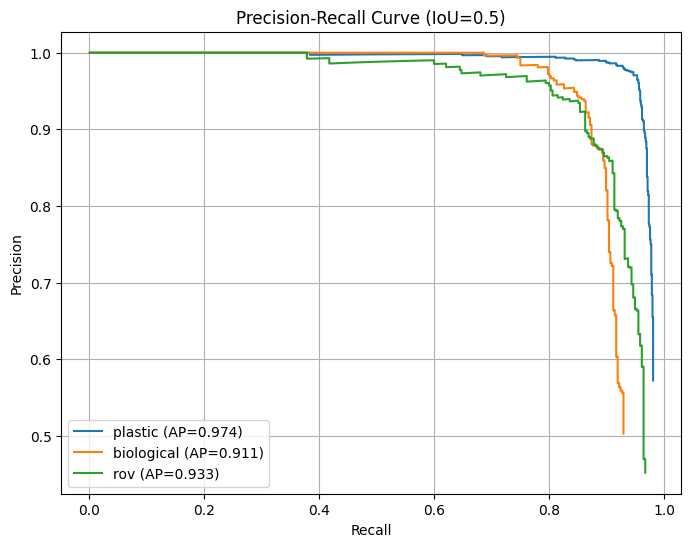

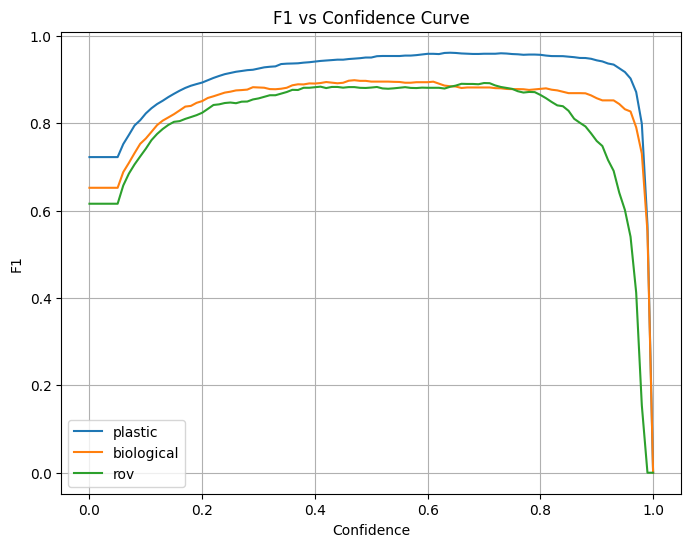

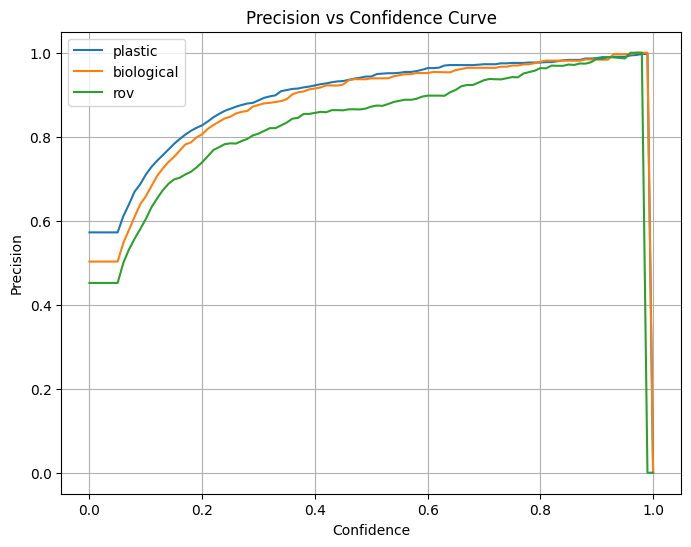

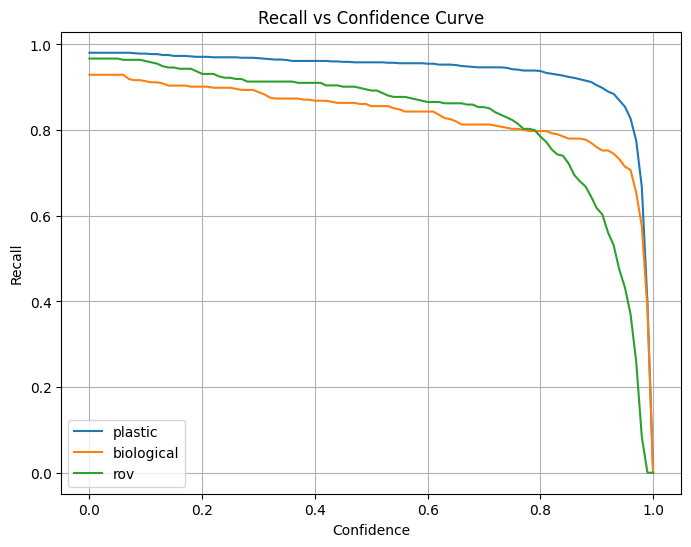

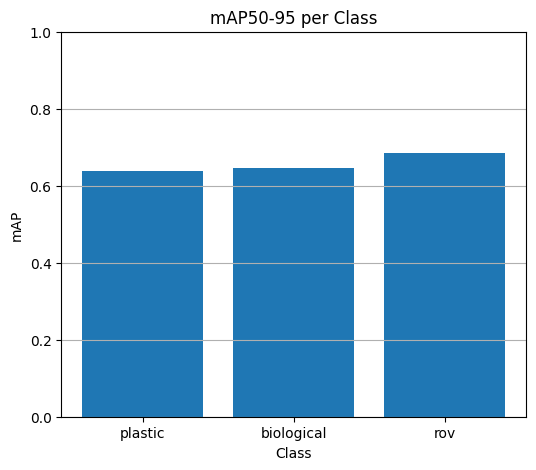


DF results:
        Class  Support  AP@50-95
0     plastic      937  0.639006
1  biological      396  0.646606
2         rov      335  0.685115


In [41]:
results = run_all_metrics_and_plots(preds_by_image, gts_by_image, NUM_CLASSES, iou_for_metrics=0.5)

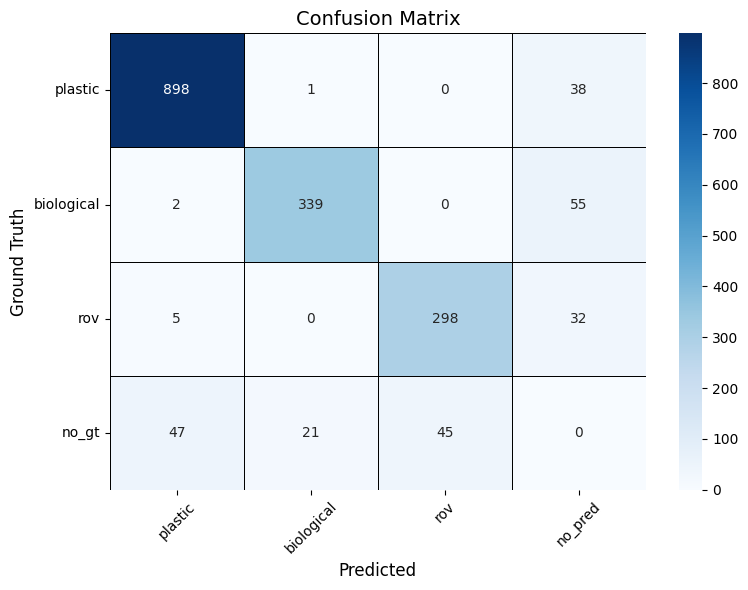

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_confusion_matrix(cm, row_labels, col_labels, figsize=(8,6), fontsize=12):
    df_cm = pd.DataFrame(cm, index=row_labels, columns=col_labels)

    plt.figure(figsize=figsize)
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues",
                cbar=True, linewidths=.5, linecolor='black')

    plt.xlabel("Predicted", fontsize=fontsize)
    plt.ylabel("Ground Truth", fontsize=fontsize)
    plt.title("Confusion Matrix", fontsize=fontsize+2)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
cm, rows, cols = detection_confusion_matrix(preds_by_image, gts_by_image, NUM_CLASSES)
plot_confusion_matrix(cm, rows, cols)